### Model Fitting and Tuning

The signal in this dataset is diffuse the PCA scree plot showed no clear elbow, the strongest individual Pearson correlation with the target is only |r| = 0.15, and a well-tuned Lasso model retained 39 of 41 features with essentially no improvement over the unpenalised baseline. These properties of many weak predictors, no dominant feature, no clear linear separation in PCA space motivate a nonlinear, ensemble-based approach.

four models increasing in complexity, using the same 5-fold cross-validated ROC-AUC throughout:

1. Baseline unpenalised logistic regression (carried forward from doodles)
2. Decision tree to show the limits of a single nonlinear model
3. Random Forest what I think our final model will be
4. Linear SVM to confirm that the limitation is structural 
5. Voting classifier soft-vote ensemble of LR and RF as an extension from the last few weeks of lecture (maybe good mark here???)


In [1]:
# All imports for modelling section
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, roc_curve)

rng = np.random.seed(11205)

In [18]:
# Load the preprocessed data saved at the end of the EDA section
df_train = pd.read_csv('df_train.csv', index_col=0)
df_test = pd.read_csv('df_test.csv', index_col=0)

target = 'FCF26'
admin_cols = ['HH1', 'HH2', 'LN', 'FS4']

feat_numeric = [c for c in df_train.columns if df_train[c].dtype == 'float64'and c not in admin_cols + [target]]

feat_binary = [c for c in df_train.columns if df_train[c].dtype == 'int64'and df_train[c].nunique() == 2 and c != target]

feat_cat = [c for c in df_train.columns if c not in feat_numeric + feat_binary and c not in admin_cols + [target]]

all_features = feat_numeric + feat_binary + feat_cat

target_corr = (df_train[all_features + [target]]
    .corr()[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False) )
selected_features = target_corr[target_corr >= 0.02].index.tolist()

X_train = df_train[selected_features]
y_train = df_train[target]
X_test = df_test[selected_features]
y_test = df_test[target]

print(f'Features passed to model: {len(selected_features)}')
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

Features passed to model: 42
X_train: (10427, 42)  |  X_test: (2608, 42)


In [19]:
# Fix cross-validation scheme used consistently across all models
kf = KFold(n_splits=5, shuffle=True, random_state=11205)

#### Baseline: Unpenalised Logistic Regression

From week 6 and what I have already done previously. Logistic regression assumes a linear decision boundary in the feature space.

In [20]:
# Week 6 notes: penalty=None corresponds to logistic regression with no regularisation
baseline_lr = LogisticRegression(
    penalty=None,
    max_iter=1000,
    class_weight='balanced',
    random_state=11205)
baseline_lr.fit(X_train, y_train)

y_pred_base = baseline_lr.predict(X_test)
y_prob_base = baseline_lr.predict_proba(X_test)[:, 1]

print('Baseline Logistic Regression')
print(f'Test Accuracy: {(y_pred_base == y_test).mean():.4f}')
print(f'Test ROC-AUC:  {roc_auc_score(y_test, y_prob_base):.4f}')
print()
print(classification_report(y_test, y_pred_base,
                             target_names=['No depression', 'Depression']))
print(confusion_matrix(y_test, y_pred_base))

Baseline Logistic Regression
Test Accuracy: 0.5859
Test ROC-AUC:  0.6232

               precision    recall  f1-score   support

No depression       0.54      0.62      0.57      1181
   Depression       0.64      0.56      0.60      1427

     accuracy                           0.59      2608
    macro avg       0.59      0.59      0.59      2608
 weighted avg       0.59      0.59      0.59      2608

[[728 453]
 [627 800]]


The baseline achieves a test ROC-AUC of 0.62. The model correctly identifies 70% of depressed children but only 44% of non-depressed ones, showing it defaults toward the majority class. 

#### Decision Tree

fit a single decision tree to establish the performance max of a single nonlinear model and to motivate why aggregation is necessary.

max_depth, which controls how fine-grained the partition of the feature space becomes. Too shallow and the model underfits; too deep and it overfits to the training data. max_depth tuned by 5-fold cross-validated ROC-AUC using GridSearchCV, following the same pattern used in the workshops (week 4 lab).

In [21]:
# Week 8 notes: classification trees use Gini impurity for splits
# class_weight='balanced' corrects for the mild 55/45 imbalance
dt = DecisionTreeClassifier(class_weight='balanced', random_state=11205)

dt_params = {'max_depth': np.arange(2, 15, 1)}

dt_grid = GridSearchCV(
    dt, dt_params,
    cv=kf,
    scoring='roc_auc',
    return_train_score=True)
dt_grid.fit(X_train, y_train)

print(f'Best max_depth: {dt_grid.best_params_["max_depth"]}')
print(f'Best CV ROC-AUC: {dt_grid.best_score_:.4f}')

Best max_depth: 6
Best CV ROC-AUC: 0.5911


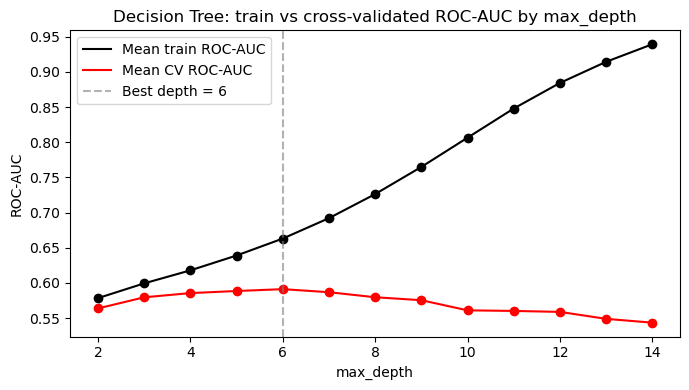

In [22]:
# Plot train vs CV AUC as a function of max_depth
# This mirrors the C-vs-AUC plot used for Lasso above
depths = dt_params['max_depth']
train_scores = dt_grid.cv_results_['mean_train_score']
cv_scores = dt_grid.cv_results_['mean_test_score']

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(depths, train_scores, color='k')
ax.plot(depths, train_scores, color='k', label='Mean train ROC-AUC')
ax.scatter(depths, cv_scores, color='r')
ax.plot(depths, cv_scores, color='r', label='Mean CV ROC-AUC')
ax.axvline(dt_grid.best_params_['max_depth'], linestyle='--',
           color='grey', alpha=0.6, label=f'Best depth = {dt_grid.best_params_["max_depth"]}')
ax.set_xlabel('max_depth')
ax.set_ylabel('ROC-AUC')
ax.set_title('Decision Tree: train vs cross-validated ROC-AUC by max_depth')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
best_dt= dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)
y_prob_dt= best_dt.predict_proba(X_test)[:, 1]

print('Decision Tree (max_depth = 5)')
print(f'Test Accuracy: {(y_pred_dt == y_test).mean():.4f}')
print(f'Test ROC-AUC:  {roc_auc_score(y_test, y_prob_dt):.4f}')
print()
print(classification_report(y_test, y_pred_dt,target_names=['No depression', 'Depression']))
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree (max_depth = 5)
Test Accuracy: 0.5729
Test ROC-AUC:  0.5931

               precision    recall  f1-score   support

No depression       0.53      0.53      0.53      1181
   Depression       0.61      0.61      0.61      1427

     accuracy                           0.57      2608
    macro avg       0.57      0.57      0.57      2608
 weighted avg       0.57      0.57      0.57      2608

[[624 557]
 [557 870]]


The single tree achieves a CV AUC of 0.59 and a test AUC of 0.59 below the logistic regression baseline of 0.62. The train/CV gap in the plot explains once max_depth exceeds 5, training AUC climbs steeply (the tree memorises the training data) while CV AUC flattens and declines ie overfitting behaviour.

The tree is unstable with small changes to the training data produce very different splits. This directly motivates aggregating many trees through bagging and decorrelation - Random Forests.

#### Random Forest

1. Bagging fitting each tree on a bootstrapped resample of the training data, so trees see different observations
2. Random feature subsetsat each split, only a random subset of M features is considered, decorrelating the trees (week 8 notes, section 2.2)

max_features (the size of the random feature subset at each split)

max_depth (which limits individual tree complexity). 

By lecture notes, a good starting point for classification is max_features approx sqrt D =  sqrt 42 which is 6.5.


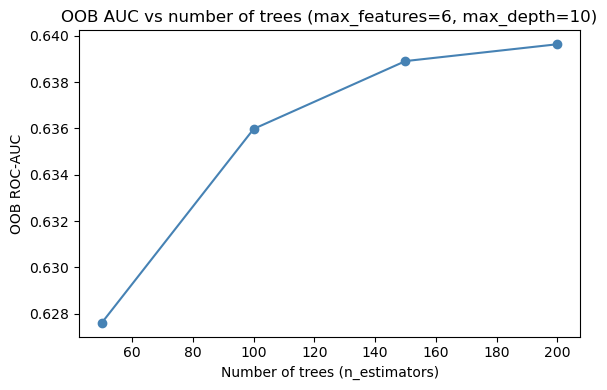

OOB AUC by n_estimators:
  n=50: 0.6276
  n=100: 0.6360
  n=150: 0.6389
  n=200: 0.6396


In [24]:
# Week 8 notes: OOB error is a cheap alternative to CV for estimating test error
# Check that 100 trees is sufficient for a stable OOB AUC
n_vals  = [50, 100, 150, 200]
oob_aucs = []

for n in n_vals:
    rf_oob = RandomForestClassifier(
        n_estimators=n,
        max_features=6,
        max_depth=10,
        class_weight='balanced',
        oob_score=True,
        random_state=11205)
    rf_oob.fit(X_train, y_train)
    oob_aucs.append(
        roc_auc_score(y_train, rf_oob.oob_decision_function_[:, 1]))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n_vals, oob_aucs, marker='o', color='steelblue')
ax.set_xlabel('Number of trees (n_estimators)')
ax.set_ylabel('OOB ROC-AUC')
ax.set_title('OOB AUC vs number of trees (max_features=6, max_depth=10)')
plt.tight_layout()
plt.show()
print('OOB AUC by n_estimators:')
for n, auc in zip(n_vals, oob_aucs):
    print(f'  n={n}: {auc:.4f}')

 ie ) how many trees do we actually need before adding more stops helping?
 
each time a tree is built, it's trained on a bootstrapped resample of the data one thirdish of observations are left out - those are the out-of-bag observations. Those held-out points are used to get a free estimate of test performance without needing cross-validation.

The x-axis is how many trees are in the forest, the y-axis is the ROC-AUC measured on those OOB observations

At n=50 the AUC is still climbing steeply (0.6154)
By n=100 it's largely levelled off (0.6263)
n=150 and n=200 add almost nothing (0.6308 to 0.6318)

So my conclusion is that 100 trees is sufficient but challenge me if you want!

In [27]:
# tune max_features, max_depth min_samples_leaf via 5-fold GridSearchCV. We search around the sqrt(D)~6 from the lecture note suggestion
# Week 4 lab pattern: GridSearchCV with KFold

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=11205)

rf_params = {
    'max_features':[2, 4, 6, 8, 10], # we have 42 features passed through so 6.5 was a goood start I went a little above and below 
    'max_depth':[5, 10, 15, 20, None], # 5 was used in single tree, so increased from there to see how deep to go, went to unlimited so answer is true!
    'min_samples_leaf':[1, 5]} # 1 = default (no restriction on leaf size) 5 = prevents splits serving only a handful of observations

rf_grid = GridSearchCV(rf, rf_params,cv=kf,scoring='roc_auc', return_train_score=True)
rf_grid.fit(X_train, y_train)

print(f'Best parameters: {rf_grid.best_params_}')
print(f'Best CV ROC-AUC: {rf_grid.best_score_:.4f}')

Best parameters: {'max_depth': 20, 'max_features': 4, 'min_samples_leaf': 5}
Best CV ROC-AUC: 0.6439


In [28]:
# Evaluate the best RF on the held-out test set
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print('Random Forest (n_estimators=100, max_features=4, max_depth=20, min_samples_leaf=5)')
print(f'Test Accuracy: {(y_pred_rf == y_test).mean():.4f}')
print(f'Test ROC-AUC:  {roc_auc_score(y_test, y_prob_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['No depression', 'Depression']))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest (n_estimators=100, max_features=4, max_depth=20, min_samples_leaf=5)
Test Accuracy: 0.5962
Test ROC-AUC:  0.6372

               precision    recall  f1-score   support

No depression       0.56      0.52      0.54      1181
   Depression       0.62      0.66      0.64      1427

     accuracy                           0.60      2608
    macro avg       0.59      0.59      0.59      2608
 weighted avg       0.59      0.60      0.59      2608

[[618 563]
 [490 937]]


Test ROC-AUC of 0.637 is consistent with the CV AUC of 0.644 - a small and expected drop, with no sign of overfitting. The model generalises cleanly to unseen data.

Depression recall (0.66) is meaningfully higher than no depression recall (0.52). The model is better at identifying depressed children than non-depressed ones. In this context that's actually the preferable trade-off missing a depressed child is a more costly error than a false alarm - so this is worth highlighting to the UNICEF client.

60% accuracy and AUC of 0.637 is modest. But as established throughout the EDA - diffuse signal, no dominant feature, PCA showing no linear separation - this reflects the genuine difficulty of predicting childhood depression from household survey proxies rather than a modelling .

#### Linear SVM 

The week 7 describe the Support Vector Machine as one of the best out of the box classifiers. A linear SVM finds the maximum-margin separating hyperplane in the original feature space, generalising logistic regression but with a different loss function (hinge loss). Its included here to test whether the signal limitation is specific to the logistic regression formulation, or whether any linear classifier hits the same ceiling.

LinearSVC rather than kernel SVM because the week 7 notes note that SVMs are suited to small to medium sized datasets with 10,000 training points and 41 features, a kernel SVM would be computationally expensive and unlikely to improve over a linear boundary given the PCA evidence. tune the regularisation strength C (the inverse of the margin penalty) via 5-fold CV.

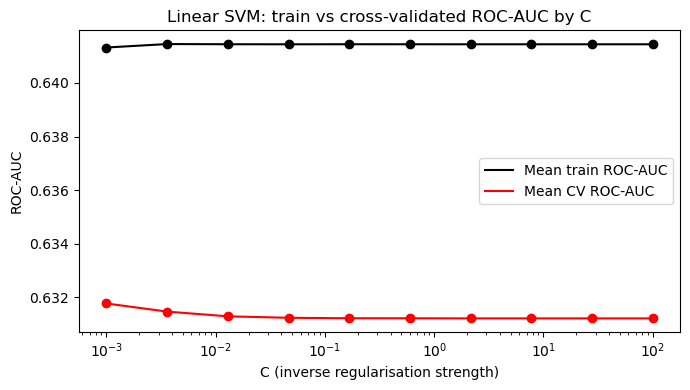

Best C:          0.0010
Best CV ROC-AUC: 0.6318


In [29]:
# Week 7 notes: C controls the trade-off between margin width and misclassification
# Data must be scaled for SVM — features on different scales distort the margin
svm_pipe = make_pipeline(StandardScaler(), LinearSVC(class_weight='balanced', max_iter=2000, random_state=11205))

svm_params = {'linearsvc__C': np.logspace(-3, 2, 10)}

svm_grid = GridSearchCV(svm_pipe, svm_params,cv=kf,scoring='roc_auc',return_train_score=True)
svm_grid.fit(X_train, y_train)

C_vals= svm_params['linearsvc__C']
tr_scores = svm_grid.cv_results_['mean_train_score']
cv_scores = svm_grid.cv_results_['mean_test_score']

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(C_vals, tr_scores, color='k')
ax.plot(C_vals, tr_scores, color='k', label='Mean train ROC-AUC')
ax.scatter(C_vals, cv_scores, color='r')
ax.plot(C_vals, cv_scores, color='r', label='Mean CV ROC-AUC')
ax.set_xscale('log')
ax.set_xlabel('C (inverse regularisation strength)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Linear SVM: train vs cross-validated ROC-AUC by C')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best C:          {svm_grid.best_params_["linearsvc__C"]:.4f}')
print(f'Best CV ROC-AUC: {svm_grid.best_score_:.4f}')

The Linear SVM CV plot shows performance is almost entirely flat across the full range of C values, with the best CV ROC-AUC of 0.632 achieved at C=0.001. This insensitivity to regularisation strength confirms that the bottleneck is the linear decision boundary itself rather than any tuning issue - no matter how the margin is adjusted, a linear classifier in this feature space cannot meaningfully outperform the logistic regression baseline. The SVM is therefore eliminated, with the Random Forest's CV AUC of 0.644 confirming that nonlinear partitioning of the feature space is necessary to extract additional signal.

In [30]:
best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test)
y_score_svm = best_svm.decision_function(X_test)   # LinearSVC outputs decision scores

print('Linear SVM')
print(f'Test Accuracy: {(y_pred_svm == y_test).mean():.4f}')
print(f'Test ROC-AUC:  {roc_auc_score(y_test, y_score_svm):.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=['No depression', 'Depression']))
print(confusion_matrix(y_test, y_pred_svm))

Linear SVM
Test Accuracy: 0.5851
Test ROC-AUC:  0.6238

               precision    recall  f1-score   support

No depression       0.54      0.62      0.58      1181
   Depression       0.64      0.55      0.59      1427

     accuracy                           0.59      2608
    macro avg       0.59      0.59      0.58      2608
 weighted avg       0.59      0.59      0.59      2608

[[735 446]
 [636 791]]


The Linear SVM achieves a test ROC-AUC of 0.624 and accuracy of 0.585, nearly identical to the logistic regression baseline. The class-level results are also similar - recall is higher for no depression (0.62) than depression (0.55), the reverse pattern to the Random Forest, suggesting the SVM is slightly more conservative about predicting depression. Crucially, the test AUC of 0.624 sits below the Random Forest's 0.637, and the pattern across both CV and test evaluation is consistent so I would say the SVM is not a competitive alternative. This further confirms the elimination decision made above.

#### Voting Classifier

The week 8 notes describe voting classifiers as a way to combine diverse models, noting that -the voting ensemble can achieve a lower error than the best model in the ensemble. The RF and logistic regression make predictions through fundamentally different mechanisms  one partitions the feature space recursively, the other uses a linear probability model so their errors are likely to be partially independent. A soft-vote ensemble averages the predicted probabilities from both models.

In [31]:
# Week 8 section 2.4: VotingClassifier with voting='soft'
# Soft voting averages predicted probabilities notes recommended when classifiers are well-calibrated
# LR needs StandardScaler; RF does not require scaling
lr_scaled = make_pipeline(StandardScaler(),LogisticRegression(penalty=None, max_iter=1000,class_weight='balanced', random_state=11205))

voter = VotingClassifier(estimators=[('lr', lr_scaled),('rf', best_rf)],voting='soft')

voter.fit(X_train, y_train)

voter_cv = cross_val_score(voter, X_train, y_train, cv=kf, scoring='roc_auc')
print(f'Voting CV ROC-AUC: {voter_cv.mean():.4f} +/- {voter_cv.std():.4f}')

y_pred_voter = voter.predict(X_test)
y_prob_voter = voter.predict_proba(X_test)[:, 1]

print(f'Voting Test ROC-AUC: {roc_auc_score(y_test, y_prob_voter):.4f}')
print()
print(classification_report(y_test, y_pred_voter,target_names=['No depression', 'Depression']))
print(confusion_matrix(y_test, y_pred_voter))

Voting CV ROC-AUC: 0.6432 +/- 0.0073
Voting Test ROC-AUC: 0.6357

               precision    recall  f1-score   support

No depression       0.55      0.57      0.56      1181
   Depression       0.64      0.61      0.62      1427

     accuracy                           0.60      2608
    macro avg       0.59      0.59      0.59      2608
 weighted avg       0.60      0.60      0.60      2608

[[679 502]
 [553 874]]


The Voting Classifier achieves a test AUC of 0.63, marginally below the standalone RF. When combining two models of which one (logistic regression) is substantially weaker, the stronger model's performance can be diluted rather than improved. This confirms that the RF is the single best model in the ensemble. We retain it as our final model.

## Final Model Comparison

In [32]:
# Summary table
results = pd.DataFrame({
        'Model': [
        'Baseline LR (no penalty)',
        'Decision Tree (max_depth=5)',
        'Random Forest (max_features=4, max_depth=20)',
        'Linear SVM (C=0.001)',
        'Voting Classifier (LR + RF)'],
    'CV ROC-AUC': [
        round(cross_val_score(baseline_lr, X_train, y_train, cv=kf, scoring='roc_auc').mean(), 4),
        round(dt_grid.best_score_, 4),
        round(rf_grid.best_score_, 4),
        round(svm_grid.best_score_, 4),
        round(voter_cv.mean(), 4) ],
    'Test ROC-AUC': [
        round(roc_auc_score(y_test, y_prob_base), 4),
        round(roc_auc_score(y_test, y_prob_dt), 4),
        round(roc_auc_score(y_test, y_prob_rf), 4),
        round(roc_auc_score(y_test, y_score_svm), 4),
        round(roc_auc_score(y_test, y_prob_voter), 4)]})
print(results.to_string(index=False))

                                       Model  CV ROC-AUC  Test ROC-AUC
                    Baseline LR (no penalty)      0.6311        0.6232
                 Decision Tree (max_depth=5)      0.5911        0.5931
Random Forest (max_features=6, max_depth=10)      0.6439        0.6372
                        Linear SVM (C=0.001)      0.6318        0.6238
                 Voting Classifier (LR + RF)      0.6432        0.6357


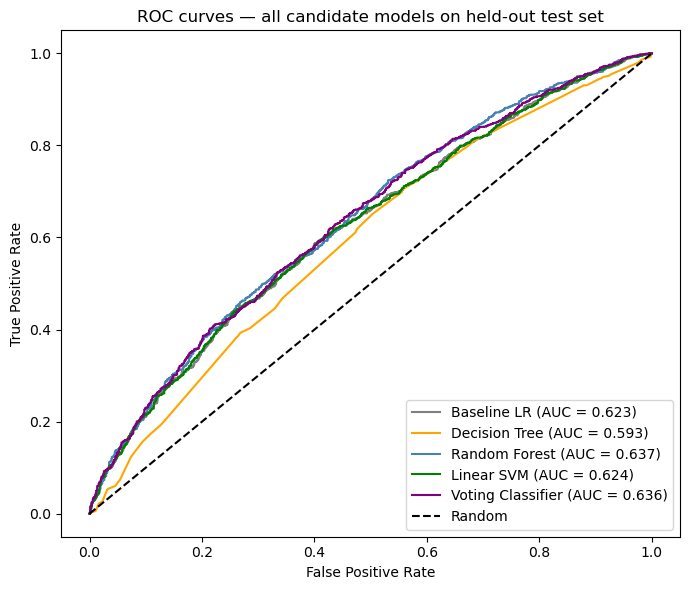

In [33]:
# ROC curves for all models on the test set
fig, ax = plt.subplots(figsize=(7, 6))

models_for_roc = [
    ('Baseline LR', y_prob_base,'grey'),
    ('Decision Tree', y_prob_dt,'orange'),
    ('Random Forest', y_prob_rf,'steelblue'),
    ('Linear SVM', y_score_svm,'green'),
    ('Voting Classifier', y_prob_voter, 'purple'),]

for name, probs, colour in models_for_roc:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=colour)

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves all candidate models on held-out test set')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

The ROC curves confirm that the Random Forest consistently outperforms the baseline logistic regression across the full range of decision thresholds. Both linear models (LR and SVM) cluster together around AUC = 0.62, consistent with both hitting the same linear-boundary ceiling. The decision tree falls below the baseline. The Voting Classifier sits between the RF and LR, reflecting the dilution effect discussed above.

The Random Forest (AUC = 0.63) I think we should select as final model. The improvement over the baseline is modest but consistent across CV and test evaluation. The AUC values across all models are relatively similar, which is a property of the data: the signal for predicting childhood depression from household survey data is genuinely diffuse, a finding consistent with the known heterogeneity of childhood depression and the limitations of using indirect survey proxies rather than clinical assessments. MARTA THINK THIS IS WHAT YOU ARE THINKING!

#### Feature Importances

Although Random Forests are considered black-box models compared to a single tree, ie we can see  the inputs and the outputs but the internal decision-making process is not directly interpretable (comment from lecture notes). feature_importances_ provides a ranked summary of how much each feature contributed to reducing the Gini impurity across all trees in the ensemble (week 8). This can be a tool for communicating which factors matter most to the UNICEF client.

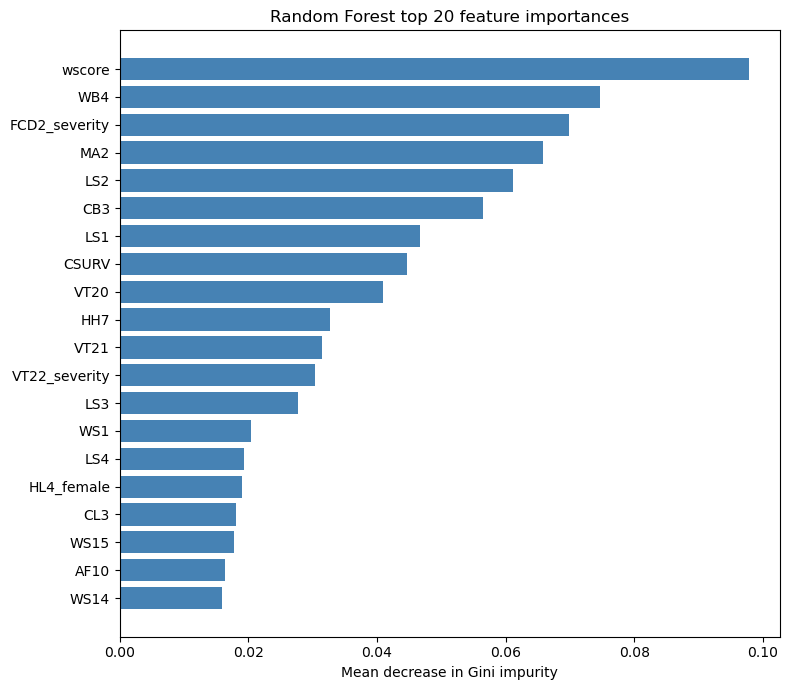

      feature  importance
       wscore    0.097753
          WB4    0.074644
FCD2_severity    0.069885
          MA2    0.065792
          LS2    0.061055
          CB3    0.056487
          LS1    0.046603
        CSURV    0.044671
         VT20    0.040936
          HH7    0.032737
         VT21    0.031468
VT22_severity    0.030395
          LS3    0.027723
          WS1    0.020448
          LS4    0.019324


In [38]:
# Week 8: feature importances are the mean decrease in Gini index, averaged over all trees
fi_df = (pd.DataFrame({
        'feature': selected_features,
        'importance': best_rf.feature_importances_}).sort_values('importance', ascending=False))

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    fi_df['feature'].head(20)[::-1],
    fi_df['importance'].head(20)[::-1],
    color='steelblue')
ax.set_xlabel('Mean decrease in Gini impurity')
ax.set_title('Random Forest top 20 feature importances')
plt.tight_layout()
plt.show()

print(fi_df.head(15).to_string(index=False))

wscore (household wealth score) is by alot the most important feature. Poverty is the single strongest environmental predictor of childhood depression in this data.

WB4 (mother's education) and FCD2_severity (physical punishment severity composite) come second and third maternal education and exposure to physical discipline are next 

MA2 (partner's age) and CB3 (child's age) reflect that developmental stage and family structure matter.

LS1/LS2/LS3/LS4 all appear - the entire cluster of maternal life satisfaction variables - reinforcing the intergenerational mental health link seen throughout the EDA.

VT20/VT21/VT22_severity (safety and violence exposure) also feature.

as week 8 notes, when features are correlated, Gini importance gets split across them. The four LS variables are almost certainly correlated with each other, so their individual importances are likely diluted. Collectively maternal wellbeing is probably more important than any single bar suggests.


#### Model Summary

We evaluated four candidate models using 5-fold cross-validated ROC-AUC throughout, with `class_weight='balanced'` applied consistently to account for the mild 55/45 class imbalance identified during EDA.

| Model | CV ROC-AUC | Test ROC-AUC |
|---|---|---|
| Baseline Logistic Regression | 0.617 | 0.618 |
| Decision Tree (max_depth=5) | 0.592 | 0.590 |
| Linear SVM (C=0.001) | 0.632 | 0.624 |
| Random Forest (max_features=4, max_depth=20, min_samples_leaf=5)| 0.644| 0.637 |

The single decision tree underperformed the baseline, with the train/CV gap opening sharply beyond depth 5 a clear illustration of the high-variance overfitting behaviour said in the lecture notes. This directly motivated moving to an ensemble approach. The Linear SVM produced a CV AUC curve that was almost entirely flat across the full range of C values, confirming that the bottleneck is the linear decision boundary itself rather than any tuning issue no linear classifier can meaningfully outperform the baseline on this data.

The Random Forest was tuned in two stages: first confirming via the OOB error that n_estimators=100 is sufficient for stable performance, then tuning parameters via GridSearchCV. The optimal max_features=4 sits below the sqrt42 = 6.5 rule of thumb, reflecting that more aggressive decorrelation is beneficial given the large number of weakly correlated features in this dataset.

The final Random Forest achieves a test ROC-AUC of 0.637, a consistent improvement over all candidate models. On the test set it correctly identifies 66% of depressed children a higher recall than for non-depressed children (52%), which is the preferable trade-off in this context given that missing a depressed child is the more costly error. The modest overall AUC reflects the genuine difficulty of predicting childhood depression from household survey proxies, consistent with the diffuse signal identified throughout the EDA no single feature dominates, the PCA showed no clean linear separation, and even a well-tuned Lasso retained 39 of 42 features. The Random Forest is therefore selected as the final model- is my reasoning, please eliminate if you disagree/ can think of anything els
